# Winter
## Notebook for reading in baseline files, computing the 25th percentile temps, saving it out

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import cartopy.crs as ccrs
from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt
import xarray as xr

import warnings
warnings.filterwarnings('ignore')

In [8]:
#import sys
#!conda install --yes --prefix {sys.prefix} dask

In [2]:
! ls -l "../../../../Data/ERA5-global/Baseline/"

total 16280
drwx------@ 26 tedscott  staff      832 Aug 27  2024 1961
drwx------@ 26 tedscott  staff      832 Aug 27  2024 1962
drwx------@ 26 tedscott  staff      832 Aug 27  2024 1963
drwx------@ 26 tedscott  staff      832 Aug 27  2024 1964
drwx------@ 26 tedscott  staff      832 Aug 27  2024 1965
drwx------@ 26 tedscott  staff      832 Aug 27  2024 1966
drwx------@ 26 tedscott  staff      832 Aug 27  2024 1967
drwx------@ 26 tedscott  staff      832 Aug 28  2024 1968
drwx------@ 26 tedscott  staff      832 Aug 28  2024 1969
drwx------@ 26 tedscott  staff      832 Aug 28  2024 1970
drwx------@ 26 tedscott  staff      832 Aug 28  2024 1971
drwx------@ 26 tedscott  staff      832 Aug 28  2024 1972
drwx------@ 26 tedscott  staff      832 Aug 28  2024 1973
drwx------@ 26 tedscott  staff      832 Aug 28  2024 1974
drwx------@ 26 tedscott  staff      832 Aug 28  2024 1975
drwx------@ 26 tedscott  staff      832 Aug 28  2024 1976
drwx------@ 26 tedscott  staff      832 Aug 28  2024 1977
dr

In [3]:
%%time
file_path = '../../../../Data/ERA5-global/Baseline/*/download_daily_mean_2m*.nc'

ds = xr.open_mfdataset(file_path)

CPU times: user 1.68 s, sys: 887 ms, total: 2.56 s
Wall time: 2.56 s


In [4]:
ds.nbytes

45504087672

In [5]:
ds

<xarray.Dataset> Size: 46GB
Dimensions:      (time: 10957, lat: 721, lon: 1440)
Coordinates:
  * time         (time) datetime64[ns] 88kB 1961-01-01 1961-01-02 ... 1990-12-31
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    realization  int64 8B 0
Data variables:
    t2m          (time, lat, lon) float32 46GB dask.array<chunksize=(31, 721, 1440), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-06-25T22:09 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

In [6]:
np.unique(ds.time.dt.year.values)

array([1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990])

In [7]:
%%time
# load it into memory
ds.load()

CPU times: user 3.87 s, sys: 50.2 s, total: 54 s
Wall time: 40min 31s


<xarray.Dataset> Size: 46GB
Dimensions:      (time: 10957, lat: 721, lon: 1440)
Coordinates:
  * time         (time) datetime64[ns] 88kB 1961-01-01 1961-01-02 ... 1990-12-31
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    realization  int64 8B 0
Data variables:
    t2m          (time, lat, lon) float32 46GB 243.9 243.9 243.9 ... 254.4 254.4
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-06-25T22:09 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

In [8]:
%%time
c_25 = ds.t2m.quantile(0.25, dim=('time'))
c_25.attrs["long_name"] = "25th percentile 2m Temperature for the data across available time dimension"
c_25.attrs["units"] = "K"
c_25

CPU times: user 2min 23s, sys: 35.2 s, total: 2min 58s
Wall time: 7min 59s


<xarray.DataArray 't2m' (lat: 721, lon: 1440)> Size: 8MB
array([[218.86286926, 218.86286926, 218.86286926, ..., 218.86286926,
        218.86286926, 218.86286926],
       [218.52233887, 218.52339172, 218.52293396, ..., 218.51637268,
        218.51916504, 218.52043152],
       [218.57655334, 218.57861328, 218.58085632, ..., 218.56170654,
        218.56726074, 218.57206726],
       ...,
       [246.8707428 , 246.86950684, 246.86828613, ..., 246.86943054,
        246.86888123, 246.86985779],
       [246.88891602, 246.88896179, 246.88874817, ..., 246.8840332 ,
        246.88557434, 246.88737488],
       [246.99066162, 246.99066162, 246.99066162, ..., 246.99066162,
        246.99066162, 246.99066162]], shape=(721, 1440))
Coordinates:
  * lat       (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon       (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    quantile  float64 8B 0.25
Attributes:
    long_name:  25th percentile 2m Temperature for the data across available ...
    units:      K

### assuming everything looks good, then the next cell writes it out

In [9]:
#'../../../Data/ERA5-global/Baseline/*/*.nc'
c_25.to_netcdf("../../../../Data/ERA5-global/Baseline/computed_1961-1990-full_25th.nc")

### and hopfully this closes the objects to free up memory

In [10]:
ds.close()
c_25.close()

In [11]:
! ls -l "../../../../Data/ERA5-global/Baseline/"

total 32560
drwx------@ 26 tedscott  staff      832 Aug 27  2024 1961
drwx------@ 26 tedscott  staff      832 Aug 27  2024 1962
drwx------@ 26 tedscott  staff      832 Aug 27  2024 1963
drwx------@ 26 tedscott  staff      832 Aug 27  2024 1964
drwx------@ 26 tedscott  staff      832 Aug 27  2024 1965
drwx------@ 26 tedscott  staff      832 Aug 27  2024 1966
drwx------@ 26 tedscott  staff      832 Aug 27  2024 1967
drwx------@ 26 tedscott  staff      832 Aug 28  2024 1968
drwx------@ 26 tedscott  staff      832 Aug 28  2024 1969
drwx------@ 26 tedscott  staff      832 Aug 28  2024 1970
drwx------@ 26 tedscott  staff      832 Aug 28  2024 1971
drwx------@ 26 tedscott  staff      832 Aug 28  2024 1972
drwx------@ 26 tedscott  staff      832 Aug 28  2024 1973
drwx------@ 26 tedscott  staff      832 Aug 28  2024 1974
drwx------@ 26 tedscott  staff      832 Aug 28  2024 1975
drwx------@ 26 tedscott  staff      832 Aug 28  2024 1976
drwx------@ 26 tedscott  staff      832 Aug 28  2024 1977
dr

## reload for maps

In [9]:
# reload it
filename = "../../../../Data/ERA5-global/Baseline/computed_1961-1990-full_25th.nc"
c_25 = xr.open_mfdataset(filename)

df_c = c_25 - 273.15
df_c.load()
df_c

<xarray.Dataset> Size: 8MB
Dimensions:   (lat: 721, lon: 1440)
Coordinates:
  * lat       (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon       (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    quantile  float64 8B 0.25
Data variables:
    t2m       (lat, lon) float64 8MB -54.29 -54.29 -54.29 ... -26.16 -26.16

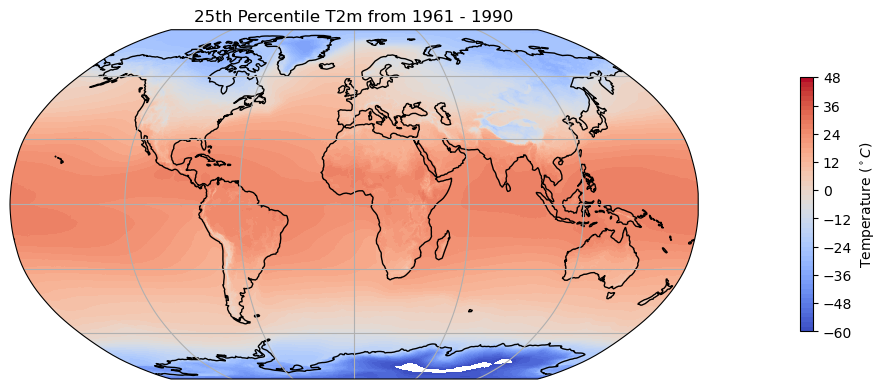

In [14]:
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

dataplot = ax.contourf(
    df_c.lon,
    df_c.lat,
    df_c.t2m,
    levels=np.arange(-60,50,2),
    transform=ccrs.PlateCarree(),
    cmap=plt.cm.coolwarm,
)

plt.title("25th Percentile T2m from 1961 - 1990")
fig.colorbar(dataplot, orientation="vertical", label="Temperature ($^\circ C$)",
             shrink=0.55, pad=0.11
            )

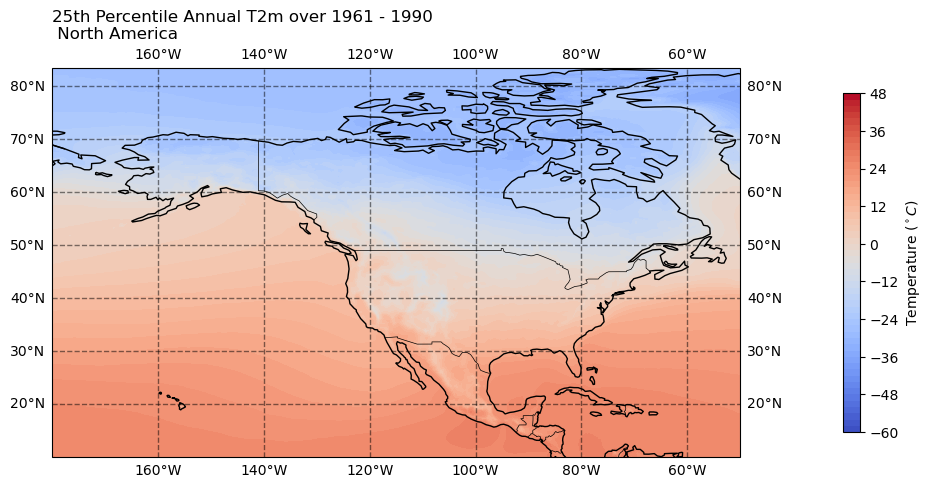

In [15]:
# make a north america map too

# try another way of plotting
fig = plt.figure(figsize=(12,8))
ax = plt.subplot(1,1,1, projection=ccrs.PlateCarree())  
ax.set_title("25th Percentile Annual T2m over 1961 - 1990 \n North America", loc="left")
dataplot = ax.contourf(
    df_c.lon,
    df_c.lat,
    df_c.t2m,
    levels=np.arange(-60,50,2),
    transform=ccrs.PlateCarree(),
    cmap=plt.cm.coolwarm,
)
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=1, color='black', alpha=0.5, linestyle='--')
ax.set_extent((-180, -50, 10, 75))
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
#ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='brown')
fig.colorbar(dataplot, orientation="vertical", label="Temperature ($^\circ C$)",
             shrink=0.55, pad=0.11
            )